<a href="https://colab.research.google.com/github/317745/ANALISIS-MONEDAS-LABORATORIO-27-05-2026/blob/main/laboratorio27_05_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
dicc_masa_monedas_individuales = {
    "monedas_50": [1.9632, 2.0231, 1.9812, 1.9872, 2.0264, 1.9744, 2.0155],
    "monedas_100": [3.3317, 3.2690, 3.3041, 3.3712, 3.2818, 3.2504, 3.3695]
                             }
df_masa_monedas_individuales = pd.DataFrame(dicc_masa_monedas_individuales)

In [136]:
dicc_masa_monedas_grupo = {
    "monedas_50": [1.9807, 3.9505, 5.9253, 7.9131, 9.9380, 11.9015, 13.9283, 15.9440, 17.9278, 19.9265],
    "monedas_100": [3.3702, 6.7918, 9.9927, 13.3624, 16.6329, 19.9737, 23.2474, 26.5797, 29.8849, 33.1672]
                      }

df_masa_monedas_grupo = pd.DataFrame(dicc_masa_monedas_grupo)

In [137]:
df_masa_monedas_individuales[:]

,monedas_50,monedas_100
0,1.9632,3.3317
1,2.0231,3.2690
2,1.9812,3.3041
3,1.9872,3.3712
4,2.0264,3.2818
5,1.9744,3.2504
6,2.0155,3.3695


In [138]:
df_masa_monedas_grupo[:]

,monedas_50,monedas_100
0,1.9807,3.3702
1,3.9505,6.7918
2,5.9253,9.9927
3,7.9131,13.3624
4,9.9380,16.6329
5,11.9015,19.9737
6,13.9283,23.2474
7,15.9440,26.5797
8,17.9278,29.8849
9,19.9265,33.1672


**ANALISIS ESTADISTICO PESO DE MONEDAS INDIVIDUALES**

In [139]:
masa_real_moneda_50 = 2.0
masa_promedio_moneda_50 = df_masa_monedas_individuales["monedas_50"].mean()
varianza_masa_moneda_50 = df_masa_monedas_individuales["monedas_50"].var()
desviacion_estandar_masa_moneda_50 = df_masa_monedas_individuales["monedas_50"].std()

In [140]:
masa_real_moneda_100 = 3.34
masa_promedio_moneda_100 = df_masa_monedas_individuales["monedas_100"].mean()
varianza_masa_moneda_100 = df_masa_monedas_individuales["monedas_100"].var()
desviacion_estandar_masa_moneda_100 = df_masa_monedas_individuales["monedas_100"].std()

In [162]:
dicc_estadisticos_monedas = {
    "monedas_50": [masa_real_moneda_50,
                    masa_promedio_moneda_50,
                    varianza_masa_moneda_50,
                    desviacion_estandar_masa_moneda_50],
    "monedas_100": [masa_real_moneda_100,
                    masa_promedio_moneda_100,
                    varianza_masa_moneda_100,
                    desviacion_estandar_masa_moneda_100]
}

filas_indice = [
    "Masa Real (g)",
    "Masa Promedio (μ)",
    "Varianza (σ²)",
    "Desviación Estándar (σ)"
]

df_estadisticos_monedas = pd.DataFrame(dicc_estadisticos_monedas, index=filas_indice)
df_estadisticos_monedas.head()

,monedas_50,monedas_100
Masa Real (g),2.000000,3.340000
Masa Promedio (μ),1.995857,3.311100
Varianza (σ²),0.000646,0.002302
Desviación Estándar (σ),0.025422,0.047978


In [156]:
sorted_masa_monedas_50 = df_masa_monedas_individuales["monedas_50"].sort_values(ascending=True).to_list()
sorted_masa_monedas_100 = df_masa_monedas_individuales["monedas_100"].sort_values(ascending=True).to_list()

def calculate_q(value, n_value, data_range):
  q_value = abs(value-n_value) / data_range
  return q_value

def build_dixon_df(array):
  array_size = len(array)
  data_range = array[-1] - array[0]
  coin_mass_q_value_dict = {"masa": [], "vecino": [], "valor_q": []}

  for i, mass in enumerate(array):
    if i == 0:
      n_value = array[i+1]

    elif i+1 == array_size:
      n_value = array[i-1]

    else:
      prev_value = array[i-1]
      diff_prev = mass-prev_value
      next_value = array[i+1]
      diff_next = next_value-mass
      n_value = prev_value if diff_next > diff_prev else next_value


    q_value = calculate_q(mass, n_value, data_range)

    coin_mass_q_value_dict["masa"].append(mass)
    coin_mass_q_value_dict["vecino"].append(n_value)
    coin_mass_q_value_dict["valor_q"].append(q_value)

  return pd.DataFrame(coin_mass_q_value_dict)


In [160]:
df_dixon_monedas_50 = build_dixon_df(sorted_masa_monedas_50)
df_dixon_monedas_50["outlier"] = df_dixon_monedas_50["valor_q"] > 0.507
df_dixon_monedas_50[:]

,masa,vecino,valor_q,outlier
0,1.9632,1.9744,0.177215,False
1,1.9744,1.9812,0.107595,False
2,1.9812,1.9872,0.094937,False
3,1.9872,1.9812,0.094937,False
4,2.0155,2.0231,0.120253,False
5,2.0231,2.0264,0.052215,False
6,2.0264,2.0231,0.052215,False


In [161]:
df_dixon_monedas_100 = build_dixon_df(sorted_masa_monedas_100)
df_dixon_monedas_100["outlier"] = df_dixon_monedas_100["valor_q"] > 0.507
df_dixon_monedas_100[:]

,masa,vecino,valor_q,outlier
0,3.2504,3.2690,0.153974,False
1,3.2690,3.2818,0.105960,False
2,3.2818,3.2690,0.105960,False
3,3.3041,3.2818,0.184603,False
4,3.3317,3.3041,0.228477,False
5,3.3695,3.3712,0.014073,False
6,3.3712,3.3695,0.014073,False


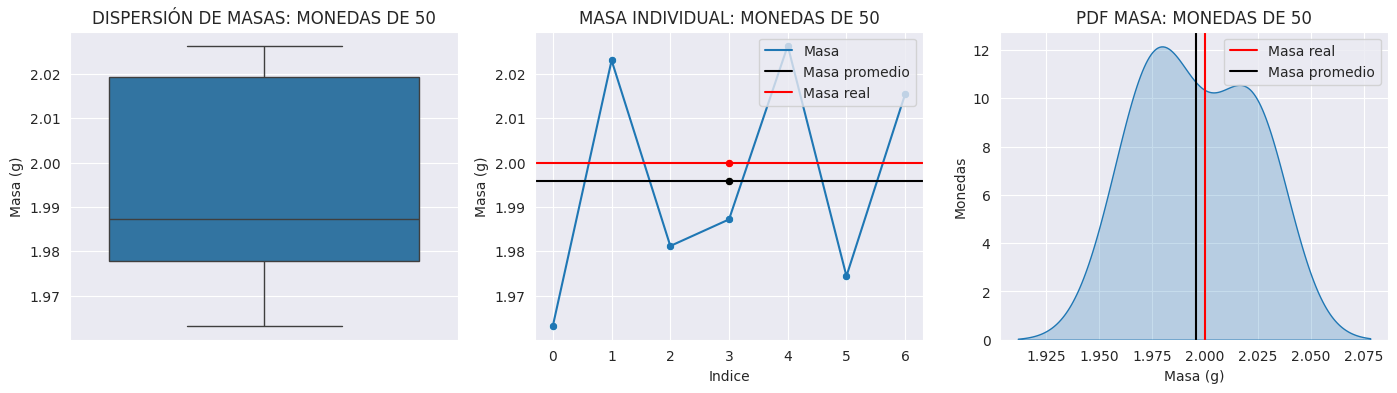

In [144]:
f, ax = plt.subplots(ncols=3, nrows=1, figsize=(17, 4))


#-----------------------------BOXPLOT-------------------------------------------
sns.boxplot(y="monedas_50",
            data=df_masa_monedas_individuales, ax=ax[0])

ax[0].set_title("DISPERSIÓN DE MASAS: MONEDAS DE 50")
ax[0].set_ylabel("Masa (g)")
ax[0].set_xlabel("")

#---------------------------SCATTERPLOT-----------------------------------------
sns.scatterplot(x=df_masa_monedas_individuales.index, y="monedas_50",
                data=df_masa_monedas_individuales, ax=ax[1])
sns.lineplot(x=df_masa_monedas_individuales.index, y="monedas_50",
                data=df_masa_monedas_individuales, ax=ax[1], label="Masa")

sns.scatterplot(x=[3], y=[masa_real_moneda_50], ax=ax[1], color="red")

sns.scatterplot(x=[3], y=[masa_promedio_moneda_50], ax=ax[1], color="black")

ax[1].axhline(y=masa_promedio_moneda_50, color="black", label="Masa promedio")
ax[1].axhline(y=masa_real_moneda_50, color="red", label="Masa real")


ax[1].set_title("MASA INDIVIDUAL: MONEDAS DE 50")
ax[1].set_ylabel("Masa (g)")
ax[1].set_xlabel("Indice")

ax[1].legend(loc="upper right")


#------------------------------KDEPLOT------------------------------------------
sns.kdeplot(x="monedas_50", fill=True,
            data=df_masa_monedas_individuales, ax=ax[2])

ax[2].set_title("PDF MASA: MONEDAS DE 50")
ax[2].set_xlabel("Masa (g)")
ax[2].set_ylabel("Monedas")

ax[2].axvline(x=masa_real_moneda_50, color="red", label="Masa real")

ax[2].axvline(x=masa_promedio_moneda_50, color="black", label="Masa promedio")

ax[2].legend(loc="upper right")


sns.set_style("darkgrid")
plt.show()

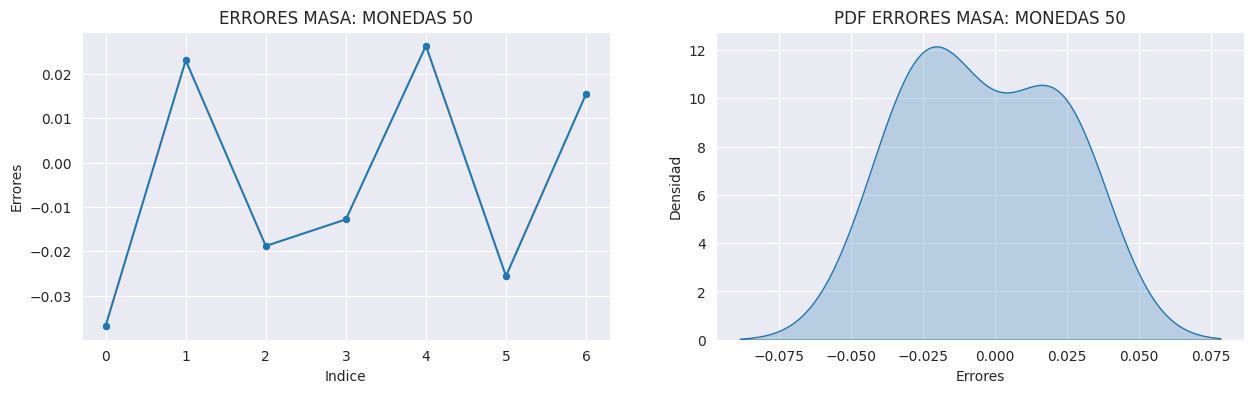

In [145]:
f, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 4))

#--------------------------------SCATTERPLOT------------------------------------
errores_masa_monedas_50 = [masa_50-masa_real_moneda_50 for masa_50 in df_masa_monedas_individuales.monedas_50]
sns.scatterplot(x=df_masa_monedas_individuales.index, y=errores_masa_monedas_50, ax=ax[0])
sns.lineplot(x=df_masa_monedas_individuales.index, y=errores_masa_monedas_50, ax=ax[0])

ax[0].set_title("ERRORES MASA: MONEDAS 50")
ax[0].set_xlabel("Indice")
ax[0].set_ylabel("Errores")

#----------------------------------KDEPLOT--------------------------------------

sns.kdeplot(x=errores_masa_monedas_50, fill=True, ax=ax[1])

ax[1].set_title("PDF ERRORES MASA: MONEDAS 50")
ax[1].set_xlabel("Errores")
ax[1].set_ylabel("Densidad")

plt.show()

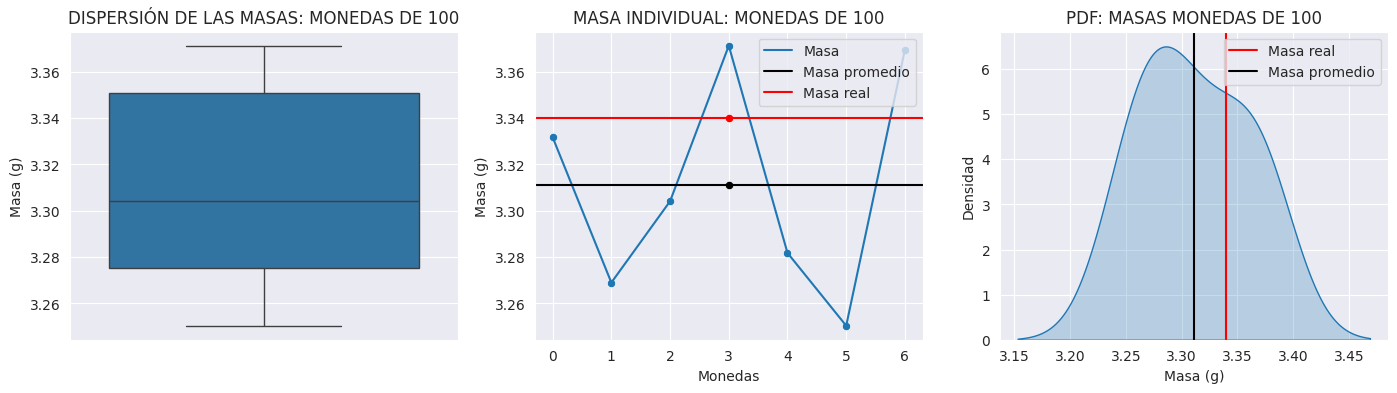

In [146]:
f, ax = plt.subplots(ncols=3, nrows=1, figsize=(17, 4))


#------------------------------BOXPLOT------------------------------------------
sns.boxplot(y="monedas_100",
            data=df_masa_monedas_individuales, ax=ax[0])

ax[0].set_title("DISPERSIÓN DE LAS MASAS: MONEDAS DE 100")
ax[0].set_ylabel("Masa (g)")
ax[0].set_xlabel("")

#----------------------------SCATTERPLOT----------------------------------------
sns.scatterplot(x=df_masa_monedas_individuales.index, y="monedas_100",
                data=df_masa_monedas_individuales, ax=ax[1])
sns.lineplot(x=df_masa_monedas_individuales.index, y="monedas_100",
                data=df_masa_monedas_individuales, ax=ax[1], label="Masa")

sns.scatterplot(x=[3], y=[masa_real_moneda_100], color="red", ax=ax[1])

sns.scatterplot(x=[3], y=[masa_promedio_moneda_100], color="black", ax=ax[1])

ax[1].axhline(y=masa_promedio_moneda_100, color="black", label="Masa promedio")
ax[1].axhline(y=masa_real_moneda_100, color="red", label="Masa real")

ax[1].set_title("MASA INDIVIDUAL: MONEDAS DE 100")
ax[1].set_ylabel("Masa (g)")
ax[1].set_xlabel("Monedas")

ax[1].legend(loc="upper right")

#---------------------KDEPLOT-----------------------------------
sns.kdeplot(x="monedas_100", fill=True,
            data=df_masa_monedas_individuales, ax=ax[2])

ax[2].axvline(x=masa_real_moneda_100, color="red", label="Masa real")

ax[2].axvline(x=masa_promedio_moneda_100, color="black", label="Masa promedio")

ax[2].set_title("PDF: MASAS MONEDAS DE 100")
ax[2].set_xlabel("Masa (g)")
ax[2].set_ylabel("Densidad")

ax[2].legend(loc="upper right")

sns.set_style("darkgrid")
plt.show()

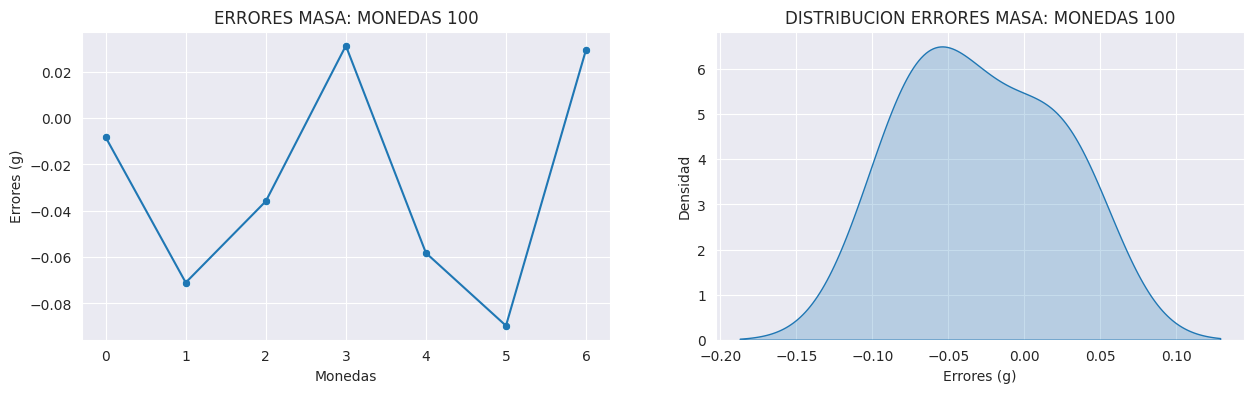

In [147]:
f, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 4))

#--------------------------------SCATTERPLOT------------------------------------
errores_masa_monedas_100 = [masa_100-masa_real_moneda_100 for masa_100 in df_masa_monedas_individuales.monedas_100]
sns.scatterplot(x=df_masa_monedas_individuales.index, y=errores_masa_monedas_100, ax=ax[0])
sns.lineplot(x=df_masa_monedas_individuales.index, y=errores_masa_monedas_100, ax=ax[0])

ax[0].set_title("ERRORES MASA: MONEDAS 100")
ax[0].set_ylabel("Errores (g)")
ax[0].set_xlabel("Monedas")

#----------------------------------KDEPLOT--------------------------------------
sns.kdeplot(x=errores_masa_monedas_100, fill=True, ax=ax[1])

ax[1].set_title("DISTRIBUCION ERRORES MASA: MONEDAS 100")
ax[1].set_xlabel("Errores (g)")
ax[1].set_ylabel("Densidad")

plt.show()

ANALISIS ESTADISTICO PESO DE MONEDAS EN GRUPOS

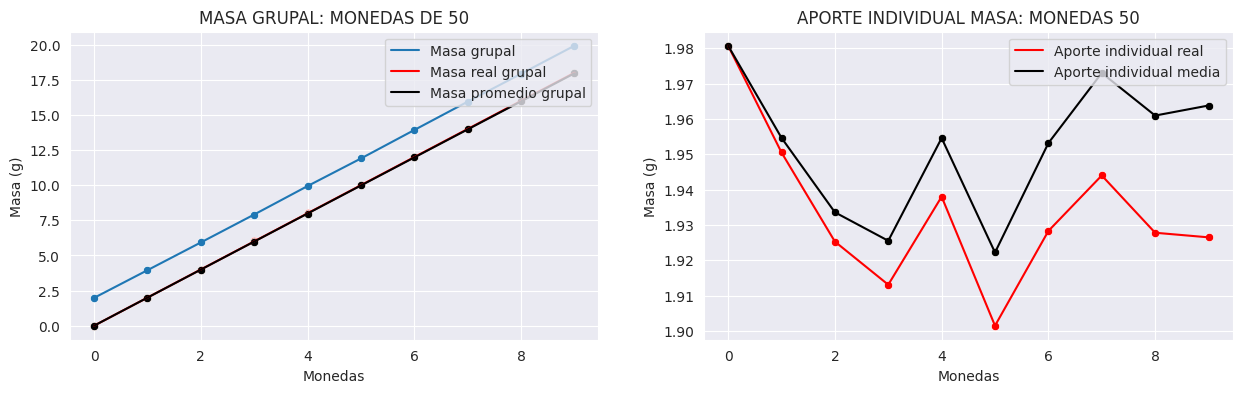

In [148]:
f, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 4))

#--------------------------------SCATTERPLOT------------------------------------
sns.scatterplot(x=df_masa_monedas_grupo.index, y="monedas_50",
                data=df_masa_monedas_grupo, ax=ax[0])
sns.lineplot(x=df_masa_monedas_grupo.index, y="monedas_50",
             data=df_masa_monedas_grupo, ax=ax[0], label="Masa grupal")

sns.scatterplot(x=df_masa_monedas_grupo.index,
                y=[masa_real_moneda_50*i for i in df_masa_monedas_grupo.index],
                data=df_masa_monedas_grupo, color="red", ax=ax[0])
sns.lineplot(x=df_masa_monedas_grupo.index,
             y=[masa_real_moneda_50*i for i in df_masa_monedas_grupo.index],
             data=df_masa_monedas_grupo, color="red", ax=ax[0], label="Masa real grupal")

sns.scatterplot(x=df_masa_monedas_grupo.index,
                y=[masa_promedio_moneda_50*i for i in df_masa_monedas_grupo.index],
                data=df_masa_monedas_grupo, color="black", ax=ax[0])
sns.lineplot(x=df_masa_monedas_grupo.index,
             y=[masa_promedio_moneda_50*i for i in df_masa_monedas_grupo.index],
             data=df_masa_monedas_grupo, color="black", ax=ax[0], label="Masa promedio grupal")


ax[0].set_title("MASA GRUPAL: MONEDAS DE 50")
ax[0].set_ylabel("Masa (g)")
ax[0].set_xlabel("Monedas")

ax[0].legend(loc="upper right")

#----------------------SCATTERPLOT-DISTRIBUCION-APORTE-INDIVIDUAL---------------

aporte_individual_real_moneda_50 = [
            fila["monedas_50"] - (masa_real_moneda_50*(indice))
            for indice, fila in df_masa_monedas_grupo[["monedas_50"]].iterrows()
                               ]
sns.scatterplot(x=df_masa_monedas_grupo.index, y = aporte_individual_real_moneda_50, color="red", ax=ax[1])
sns.lineplot(x=df_masa_monedas_grupo.index, y = aporte_individual_real_moneda_50, color="red", ax=ax[1], label="Aporte individual real")

aporte_individual_media_moneda_50 = [
            fila["monedas_50"] - (masa_promedio_moneda_50*(indice))
            for indice, fila in df_masa_monedas_grupo[["monedas_50"]].iterrows()
                                    ]

sns.scatterplot(x=df_masa_monedas_grupo.index, y = aporte_individual_media_moneda_50, color="black", ax=ax[1])
sns.lineplot(x=df_masa_monedas_grupo.index, y = aporte_individual_media_moneda_50, color="black", ax=ax[1], label="Aporte individual media")

ax[1].set_title("APORTE INDIVIDUAL MASA: MONEDAS 50")
ax[1].set_ylabel("Masa (g)")
ax[1].set_xlabel("Monedas")

ax[1].legend(loc="upper right")


sns.set_style("darkgrid")

plt.show()

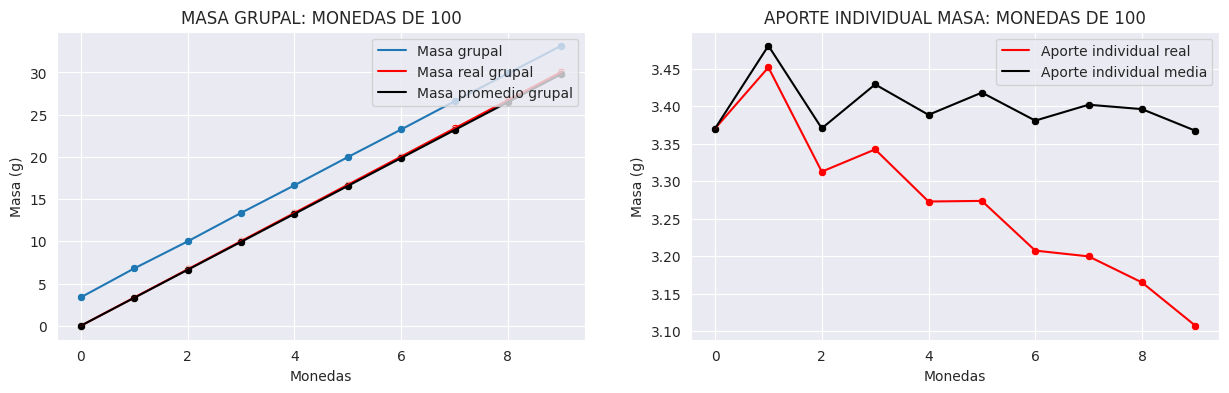

In [149]:
f, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 4))

#---------------------------------SCATTERPLOT-----------------------------------

sns.scatterplot(x=df_masa_monedas_grupo.index, y="monedas_100",
                data=df_masa_monedas_grupo, ax=ax[0])
sns.lineplot(x=df_masa_monedas_grupo.index, y="monedas_100",
                data=df_masa_monedas_grupo, ax=ax[0], label="Masa grupal")

sns.scatterplot(x=df_masa_monedas_grupo.index,
                y=[masa_real_moneda_100*i for i in df_masa_monedas_grupo.index],
                data=df_masa_monedas_grupo, color="red", ax=ax[0])
sns.lineplot(x=df_masa_monedas_grupo.index,
             y=[masa_real_moneda_100*i for i in df_masa_monedas_grupo.index],
             data=df_masa_monedas_grupo, color="red", ax=ax[0], label="Masa real grupal")

sns.scatterplot(x=df_masa_monedas_grupo.index,
                y=[masa_promedio_moneda_100*i for i in df_masa_monedas_grupo.index],
                data=df_masa_monedas_grupo, color="black", ax=ax[0])
sns.lineplot(x=df_masa_monedas_grupo.index,
             y=[masa_promedio_moneda_100*i for i in df_masa_monedas_grupo.index],
             data=df_masa_monedas_grupo, color="black", ax=ax[0], label="Masa promedio grupal")

ax[0].set_title("MASA GRUPAL: MONEDAS DE 100")
ax[0].set_ylabel("Masa (g)")
ax[0].set_xlabel("Monedas")

ax[0].legend(loc="upper right")

#------------------SCATTERPLOT-DISTRIBUCION-APORTE-INDIVIDUAL-------------------

aporte_individual_moneda_100 = [
            fila["monedas_100"] - (masa_real_moneda_100*(indice))
            for indice, fila in df_masa_monedas_grupo[["monedas_100"]].iterrows()
                               ]
sns.scatterplot(x=df_masa_monedas_grupo.index, y = aporte_individual_moneda_100, color="red", ax=ax[1])
sns.lineplot(x=df_masa_monedas_grupo.index, y = aporte_individual_moneda_100, color="red", ax=ax[1], label="Aporte individual real")

aporte_individual_media_moneda_100 = [
            fila["monedas_100"] - (masa_promedio_moneda_100*(indice))
            for indice, fila in df_masa_monedas_grupo[["monedas_100"]].iterrows()
                                    ]

sns.scatterplot(x=df_masa_monedas_grupo.index, y = aporte_individual_media_moneda_100, color="black", ax=ax[1])
sns.lineplot(x=df_masa_monedas_grupo.index, y = aporte_individual_media_moneda_100, color="black", ax=ax[1], label="Aporte individual media")

ax[1].set_title("APORTE INDIVIDUAL MASA: MONEDAS DE 100")
ax[1].set_ylabel("Masa (g)")
ax[1].set_xlabel("Monedas")

ax[1].legend(loc="upper right")

sns.set_style("darkgrid")

plt.show()

https://www.banrep.gov.co/es/billetes-monedas/moneda-100-nueva


https://www.banrep.gov.co/es/billetes-monedas/moneda-50-nueva


https://www.studocu.com/bo/document/universidad-mayor-de-san-andres/fisica-basica/tabla-de-q-de-dixon-dasdasdasdas/102948563
